In [21]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
#set color
sns.set_palette('Blues_d')

In [23]:
#Read Data set
df = pd.read_csv('/workspaces/EDA-Project/Data/california_housing_prices.csv')

In [24]:
#inspecting shape
print(f'California Dataset contains no of rows: {df.shape[0]} and no. of columns:{df.shape[1]} ')

California Dataset contains no of rows: 20640 and no. of columns:10 


In [25]:
#inspecting duplicate record
print(f'California housing dataset contains {sum(df.duplicated())} duplicate records')

California housing dataset contains 0 duplicate records


In [26]:
#datafram info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [27]:
#Missing Values
round(df.isna().sum()*100/df.shape[0],2)


longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

In [28]:
#statical description
df[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']].describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


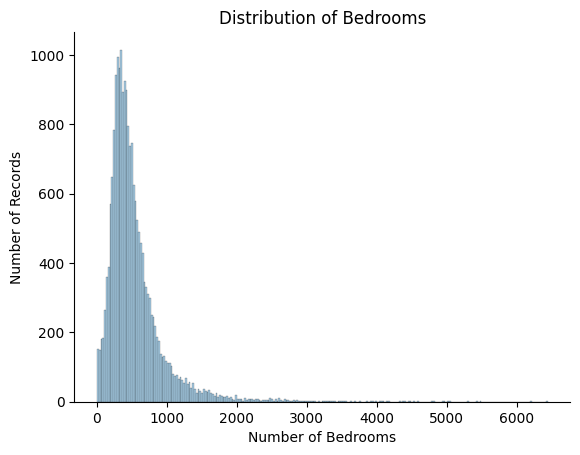

In [29]:
#distribution and concentaration of bedrooms
sns.histplot(data = df, x = 'total_bedrooms')
plt.title('Distribution of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Records')
plt.gca().spines[['right','top']].set_visible(False)
plt.show()

In [30]:
#imputting missing values in total bedrooms with median

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

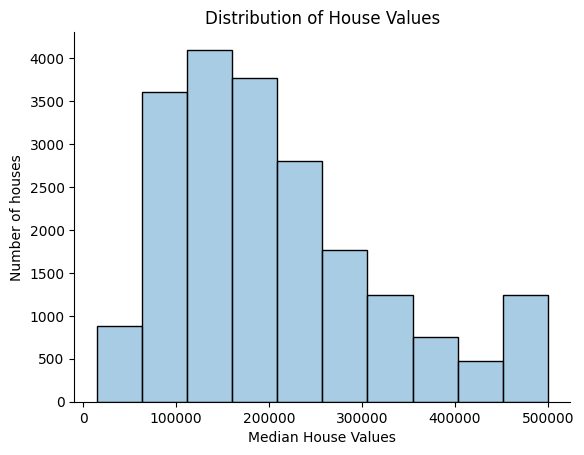

In [31]:
#how are house value distributed
sns.histplot(data = df, x = 'median_house_value', binwidth = 50000)
plt.title('Distribution of House Values')
plt.xlabel('Median House Values')
plt.ylabel('Number of houses')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()


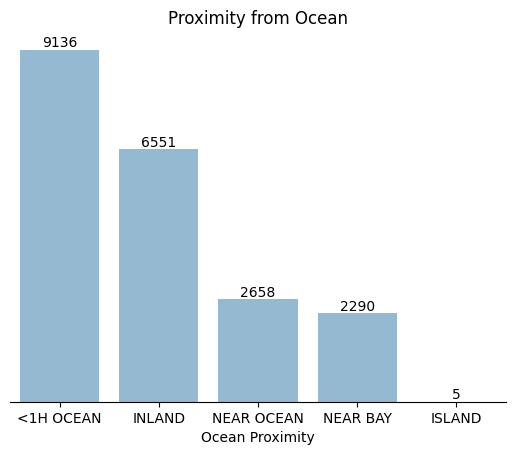

In [32]:
#how many housing blocks fall into ocean proximity
fig = sns.countplot(data = df, x = 'ocean_proximity', order = df['ocean_proximity'].value_counts().index)
for p in fig.patches:
    plt.text(p.get_x()+p.get_width()/2, p.get_height(), f'{int(p.get_height())}', ha = 'center', va = 'bottom')
plt.title('Proximity from Ocean')
plt.xlabel('Ocean Proximity')
plt.ylabel('')
plt.yticks([])
plt.gca().spines[['top','left','right']].set_visible(False)
plt.show()

In [33]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

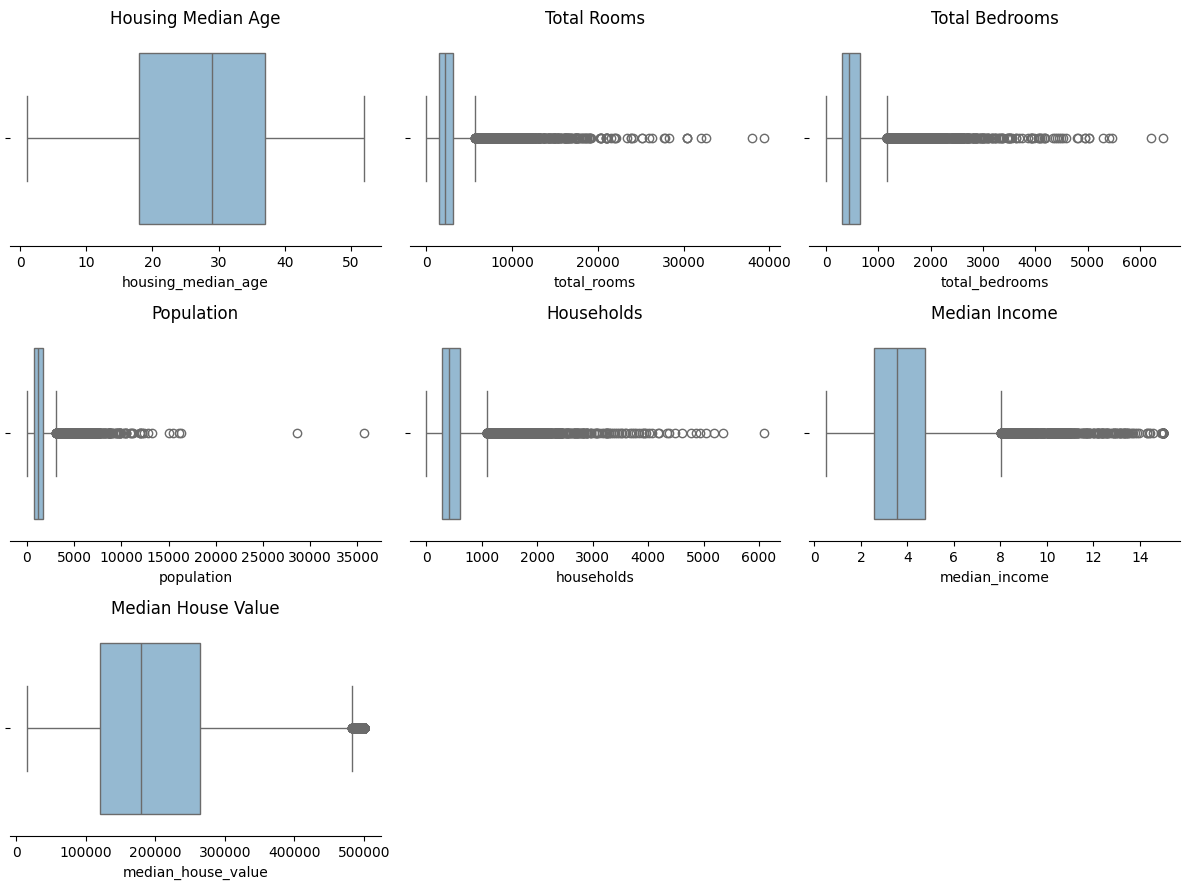

In [46]:
#outlier detection using box plot
cols = ['housing_median_age', 'total_rooms','total_bedrooms', 'population', 'households', 'median_income','median_house_value']
fig, axs = plt.subplots(nrows = 3, ncols = 3, figsize = (12,9))
axs = axs.flatten()
#iterating using for loop
for i, col in enumerate(cols):
    sns.boxplot(data = df, x = col, ax = axs[i])
    axs[i].set_title(col.replace('_',' ').title())
    plt.xlabel('')
    plt.ylabel('')
    plt.yticks([])
    axs[i].spines[['top','left','right']].set_visible(False)
for j in range(len(cols), len(axs)):
    axs[j].set_visible(False)
plt.tight_layout()
plt.show()

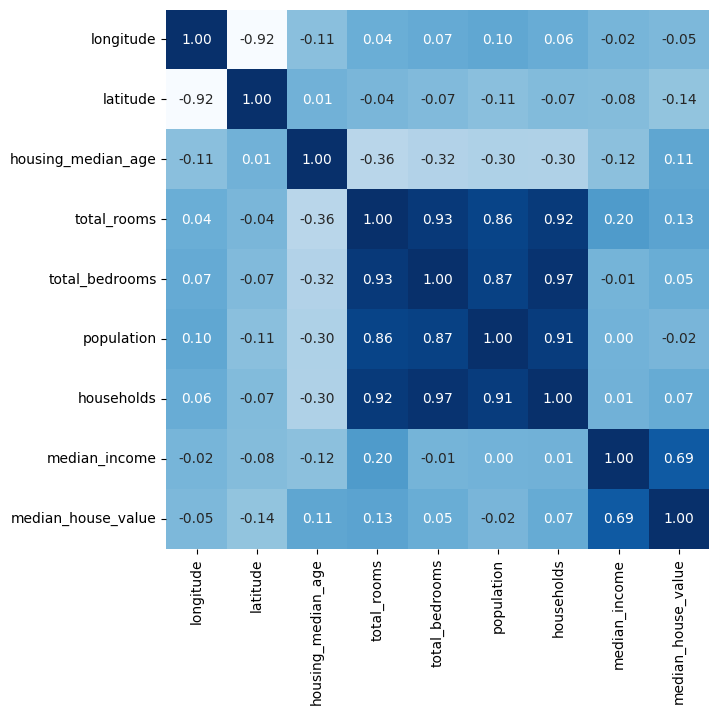

In [49]:
#correlation
plt.figure(figsize = (7,7))
sns.heatmap(df.drop('ocean_proximity', axis = 1).corr(),annot = True,fmt = '.2f',cmap = 'Blues', cbar = False)
plt.show()
           


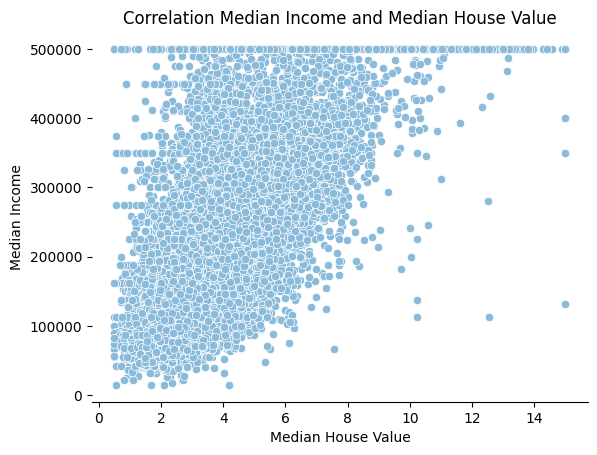

In [54]:
#correlation between Houses Value and Income
sns.scatterplot(data = df, x = 'median_income', y = 'median_house_value')
plt.title('Correlation Median Income and Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Median Income')
plt.gca().spines[['top','left','right']].set_visible(False)
plt.show()

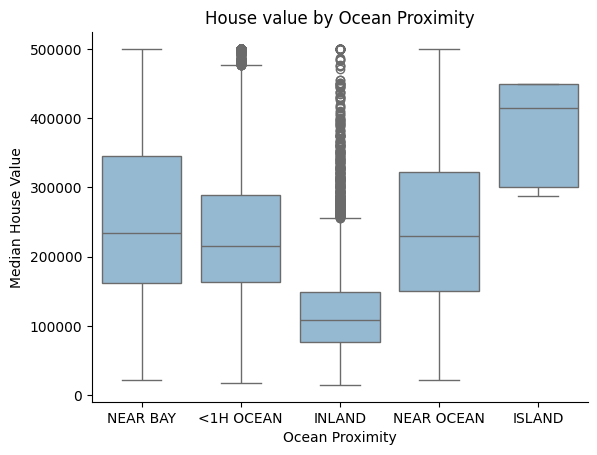

In [59]:
#how does Ocean proximity influence house value
sns.boxplot(data = df, x = 'ocean_proximity', y='median_house_value')
plt.title('House value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()